In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
path = 'Modeling_results/'
csv_files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith('_true.csv')]

true_dfs, pred_dfs = [], []
for true_path in csv_files:
    #if '1' in true_path: continue
    number = true_path.replace('Modeling_results/', '').replace('_true.csv', '')
    if(int(number) >= 8): continue
    pred_path = true_path.replace('_true.csv', '_predicted.csv')
    true_dfs.append(pd.read_csv(true_path))
    pred_dfs.append(pd.read_csv(pred_path))

pd_true = pd.concat(true_dfs, ignore_index=True)
pd_pred = pd.concat(pred_dfs, ignore_index=True)

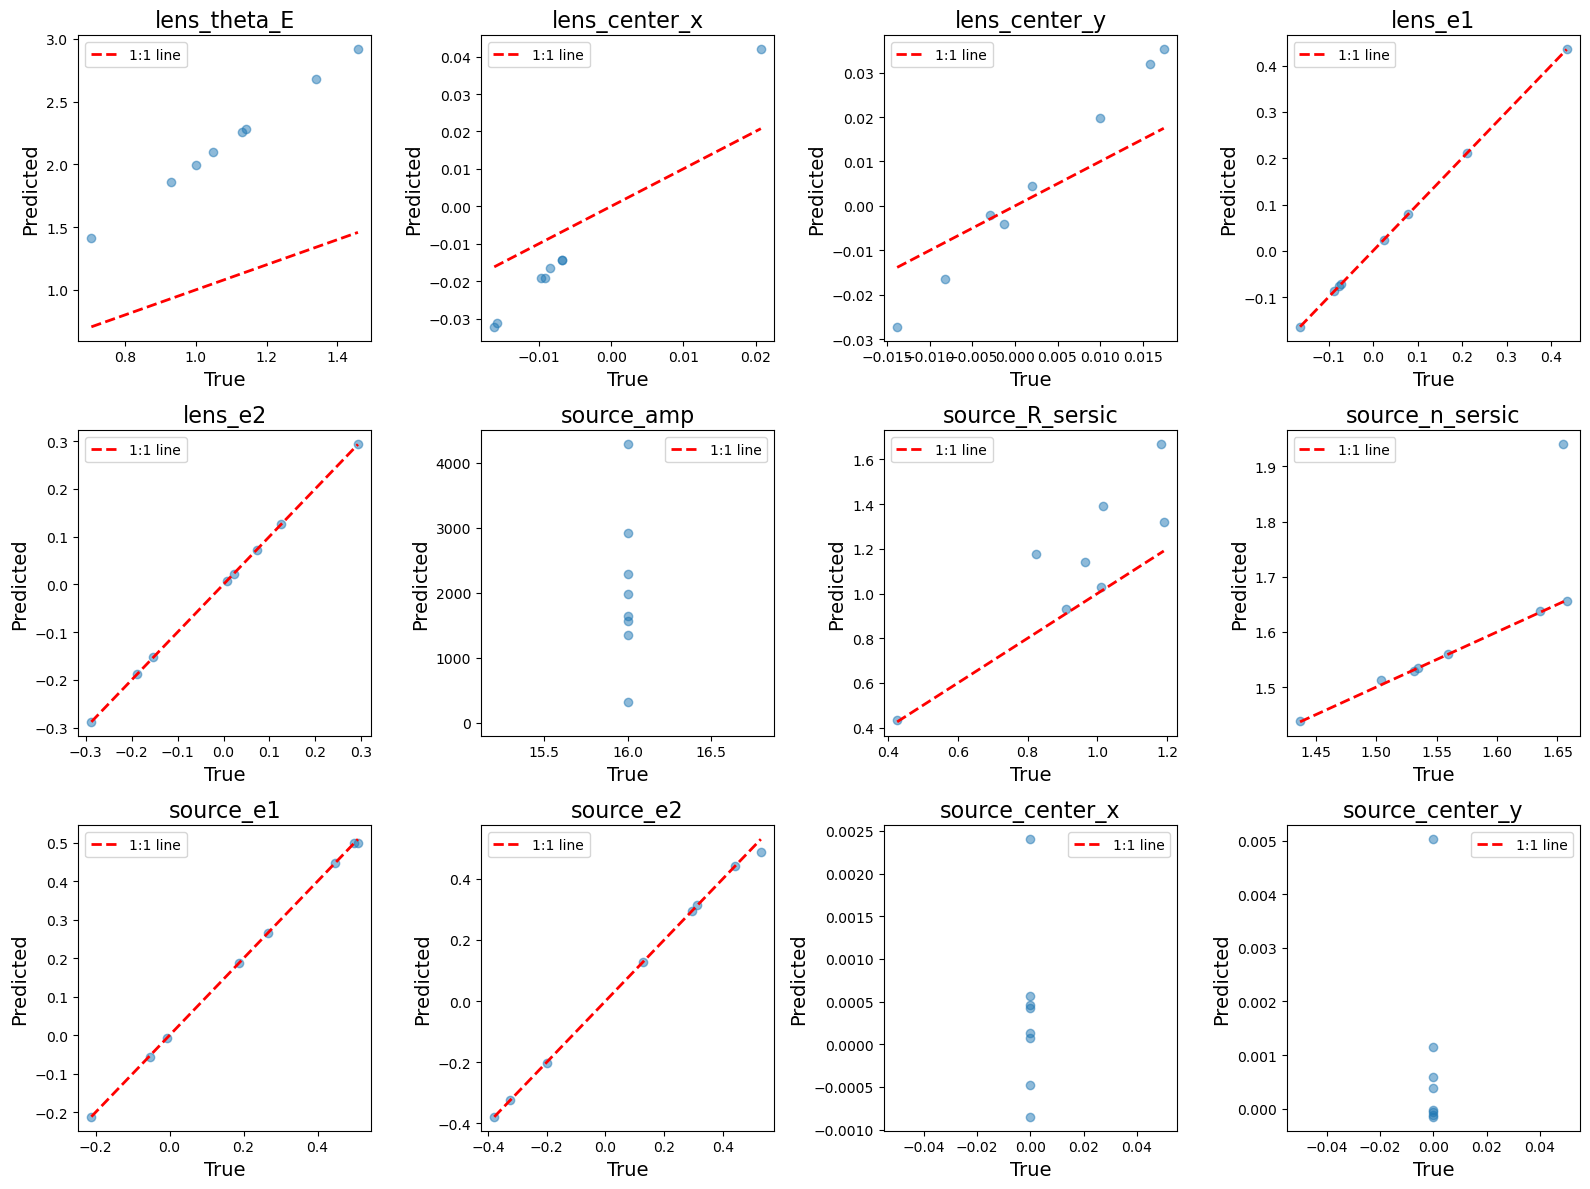

In [21]:
cols = pd_true.columns
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    ax.scatter(pd_true[col], pd_pred[col], alpha=0.5)
    ax.plot([pd_true[col].min(), pd_true[col].max()],
            [pd_true[col].min(), pd_true[col].max()],
            'r--', lw=2, label='1:1 line')
    ax.set_xlabel('True', fontsize=14)
    ax.set_ylabel('Predicted', fontsize=14)
    ax.set_title(col, fontsize=16)
    ax.legend()

plt.tight_layout()
plt.show()